In [30]:
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as cp

In [49]:
T = np.array([277,281,285,289,293])
nu = np.array([1.366,1.243,1.148,1.005,0.948])*1e-3
ap = np.array([1.721,1.947,2.396,3.213,3.537])*1e-4

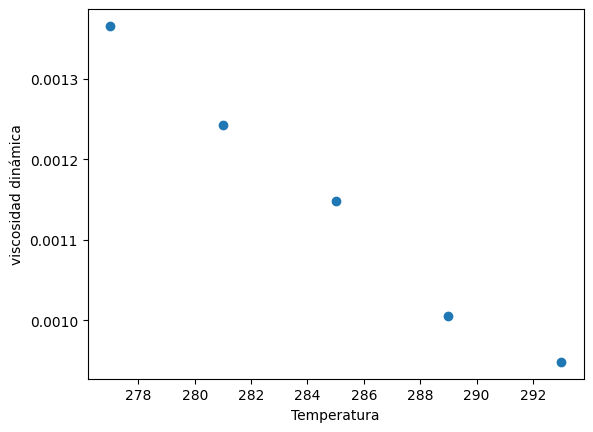

In [50]:
fig, ax = plt.subplots()
ax.scatter(T,nu)
ax.set_ylabel("viscosidad dinámica")
ax.set_xlabel("Temperatura");

In [51]:
x = 1 / T
y = np.log(nu)
m, n = np.polyfit(x, y, 1)
B = m
A = np.exp(n)
print(f"Parámetro A: {A}")
print(f"Parámetro B: {B}")

Parámetro A: 1.3686547347844438e-06
Parámetro B: 1913.7989961446747


In [52]:
def nu_from_T(T):
    return  1.3686547347844438e-06*np.exp(1913.7989961446747/T)

In [53]:
Trange = np.arange(277, 294,1)
nu_fit = nu_from_T(np.arange(277, 294,1))

In [54]:
P_indise = 101325  # 1 bar en Pascales
nu_coolprop = [
    cp.PropsSI("V", "T", t, "P", P_indise, "Water")
    for t in Trange
]

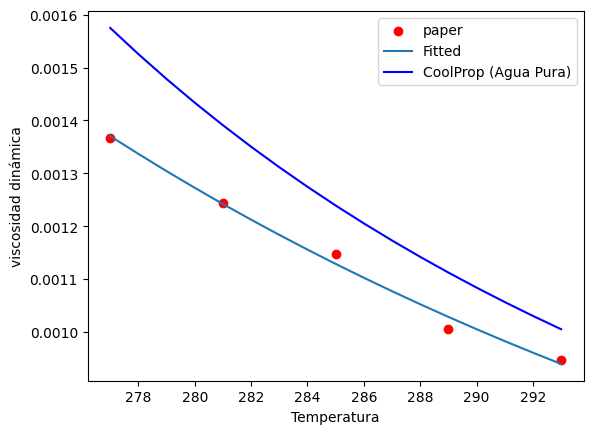

In [55]:
fig, ax = plt.subplots()
ax.scatter(T,nu, label = "paper", color = "red")
ax.plot(np.arange(277, 294,1), nu_fit, label = "Fitted")
ax.plot(Trange, nu_coolprop, label="CoolProp (Agua Pura)", color="blue")
ax.set_ylabel("viscosidad dinámica")
ax.set_xlabel("Temperatura");
ax.legend();

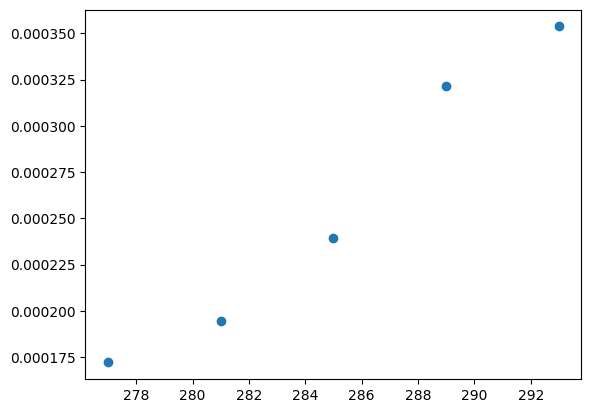

In [20]:
plt.scatter(T,ap)

In [43]:
a, b, c = np.polyfit(T, ap, 2)
print(f"Ecuación ajustada: ap(T) = ({a:.4e})*T^2 + ({b:.4e})*T + ({c:.4e})")

Ecuación ajustada: ap(T) = (2.5179e-07)*T^2 + (-1.3127e-04)*T + (1.7210e-02)


In [44]:
def ap_from_T(T):
    return (2.5179e-7) * (T**2) + (-1.3127e-4) * T + (1.7210e-2)
ap_fit = ap_from_T(Trange)

    

In [45]:
P_indise = 101325  # 1 bar en Pascales
ap_coolprop = [
    cp.PropsSI("isobaric_expansion_coefficient", "T", t, "P", P_indise, "Water")
    for t in Trange
]

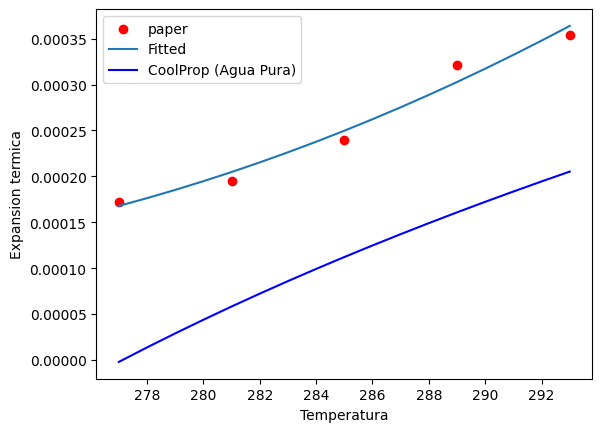

In [46]:
fig, ax = plt.subplots()
ax.scatter(T,ap, label = "paper", color = "red")
ax.plot(Trange, ap_fit, label = "Fitted")
ax.plot(Trange, ap_coolprop, label="CoolProp (Agua Pura)", color="blue")
ax.set_ylabel("Expansion termica")
ax.set_xlabel("Temperatura");
ax.legend();